# 📊 Análisis Exploratorio de Datos — Student Depression

**Proyecto:** Predicción de riesgo de depresión en estudiantes  
**Objetivo del EDA:** entender la estructura de los datos, su calidad, la distribución de la variable objetivo (`Depression`) y las relaciones entre las variables predictoras y el objetivo, para preparar la fase de modelado.

> ⚠️ **Nota ética:** los datos tratan sobre salud mental. Se usan solo con fines académicos; el análisis **no** constituye diagnóstico clínico.

## 1. Configuración e importación de librerías

In [1]:
import sys
from pathlib import Path

# Permite importar el paquete `src` desde la carpeta notebooks/
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loaders import load_raw_data
from src.data.utils import dataframe_summary, target_balance
from src.config.constants import TARGET, NUMERIC_FEATURES, CATEGORICAL_FEATURES

# Estilo de gráficos
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

print("Librerías cargadas correctamente ✅")

Librerías cargadas correctamente ✅


## 2. Carga de datos y primera mirada

In [2]:
df = load_raw_data()
print(f"Dimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head()

Dimensiones del dataset: 27,901 filas × 18 columnas


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  str    
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  str    
 4   Profession                             27901 non-null  str    
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  str    
 11  Dietary Habit

In [4]:
# Estadísticos descriptivos de las variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,27901.0,70442.149421,40641.175216,2.0,35039.00,70684.00,105818.00,140699.0
Age,27901.0,25.822300,4.905687,18.0,21.00,25.00,30.00,59.0
Academic Pressure,27901.0,3.141214,1.381465,0.0,2.00,3.00,4.00,5.0
Work Pressure,27901.0,0.000430,0.043992,0.0,0.00,0.00,0.00,5.0
CGPA,27901.0,7.656104,1.470707,0.0,6.29,7.77,8.92,10.0
Study Satisfaction,27901.0,2.943837,1.361148,0.0,2.00,3.00,4.00,5.0
Job Satisfaction,27901.0,0.000681,0.044394,0.0,0.00,0.00,0.00,4.0
Work/Study Hours,27901.0,7.156984,3.707642,0.0,4.00,8.00,10.00,12.0
Financial Stress,27898.0,3.139867,1.437347,1.0,2.00,3.00,4.00,5.0
Depression,27901.0,0.585499,0.492645,0.0,0.00,1.00,1.00,1.0


## 3. Calidad de los datos

Revisamos tipos, valores faltantes, valores únicos y duplicados.

In [5]:
# Resumen por columna: tipo, nº y % de nulos, valores únicos
dataframe_summary(df)

,dtype,n_missing,pct_missing,n_unique
Financial Stress,float64,3,0.01,5
id,int64,0,0.00,27901
Gender,str,0,0.00,2
Age,float64,0,0.00,34
Profession,str,0,0.00,14
City,str,0,0.00,52
Work Pressure,float64,0,0.00,3
CGPA,float64,0,0.00,332
Study Satisfaction,float64,0,0.00,6
Academic Pressure,float64,0,0.00,6


In [6]:
# Filas duplicadas
n_dup = df.duplicated().sum()
print(f"Filas duplicadas: {n_dup}")

Filas duplicadas: 0


## 4. Variable objetivo: `Depression`

Analizamos el balance de clases. Un dataset muy desbalanceado exigiría técnicas
específicas (métricas adecuadas, remuestreo, etc.).

In [7]:
target_balance(df, TARGET)

,count,pct
Depression,,
1,16336,58.55
0,11565,41.45


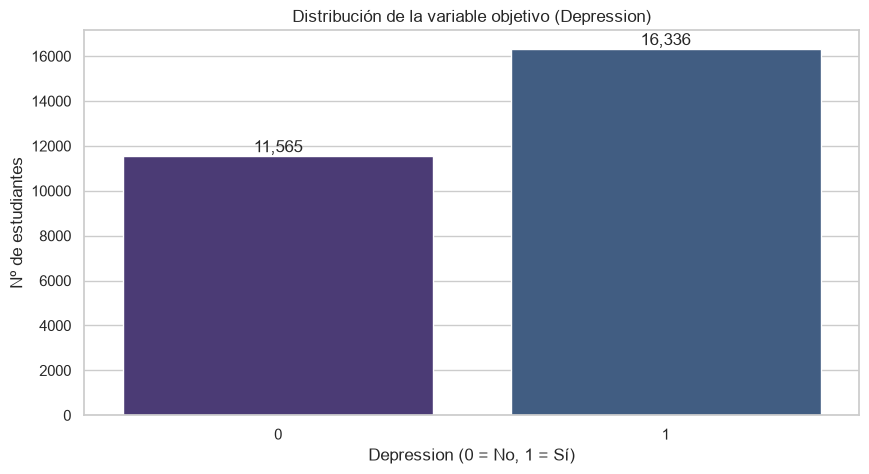

In [8]:
ax = sns.countplot(data=df, x=TARGET, hue=TARGET, legend=False)
ax.set_title("Distribución de la variable objetivo (Depression)")
ax.set_xlabel("Depression (0 = No, 1 = Sí)")
ax.set_ylabel("Nº de estudiantes")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.show()

## 5. Análisis univariado — variables numéricas

Distribución de cada variable numérica para detectar sesgos, rangos atípicos y escalas.

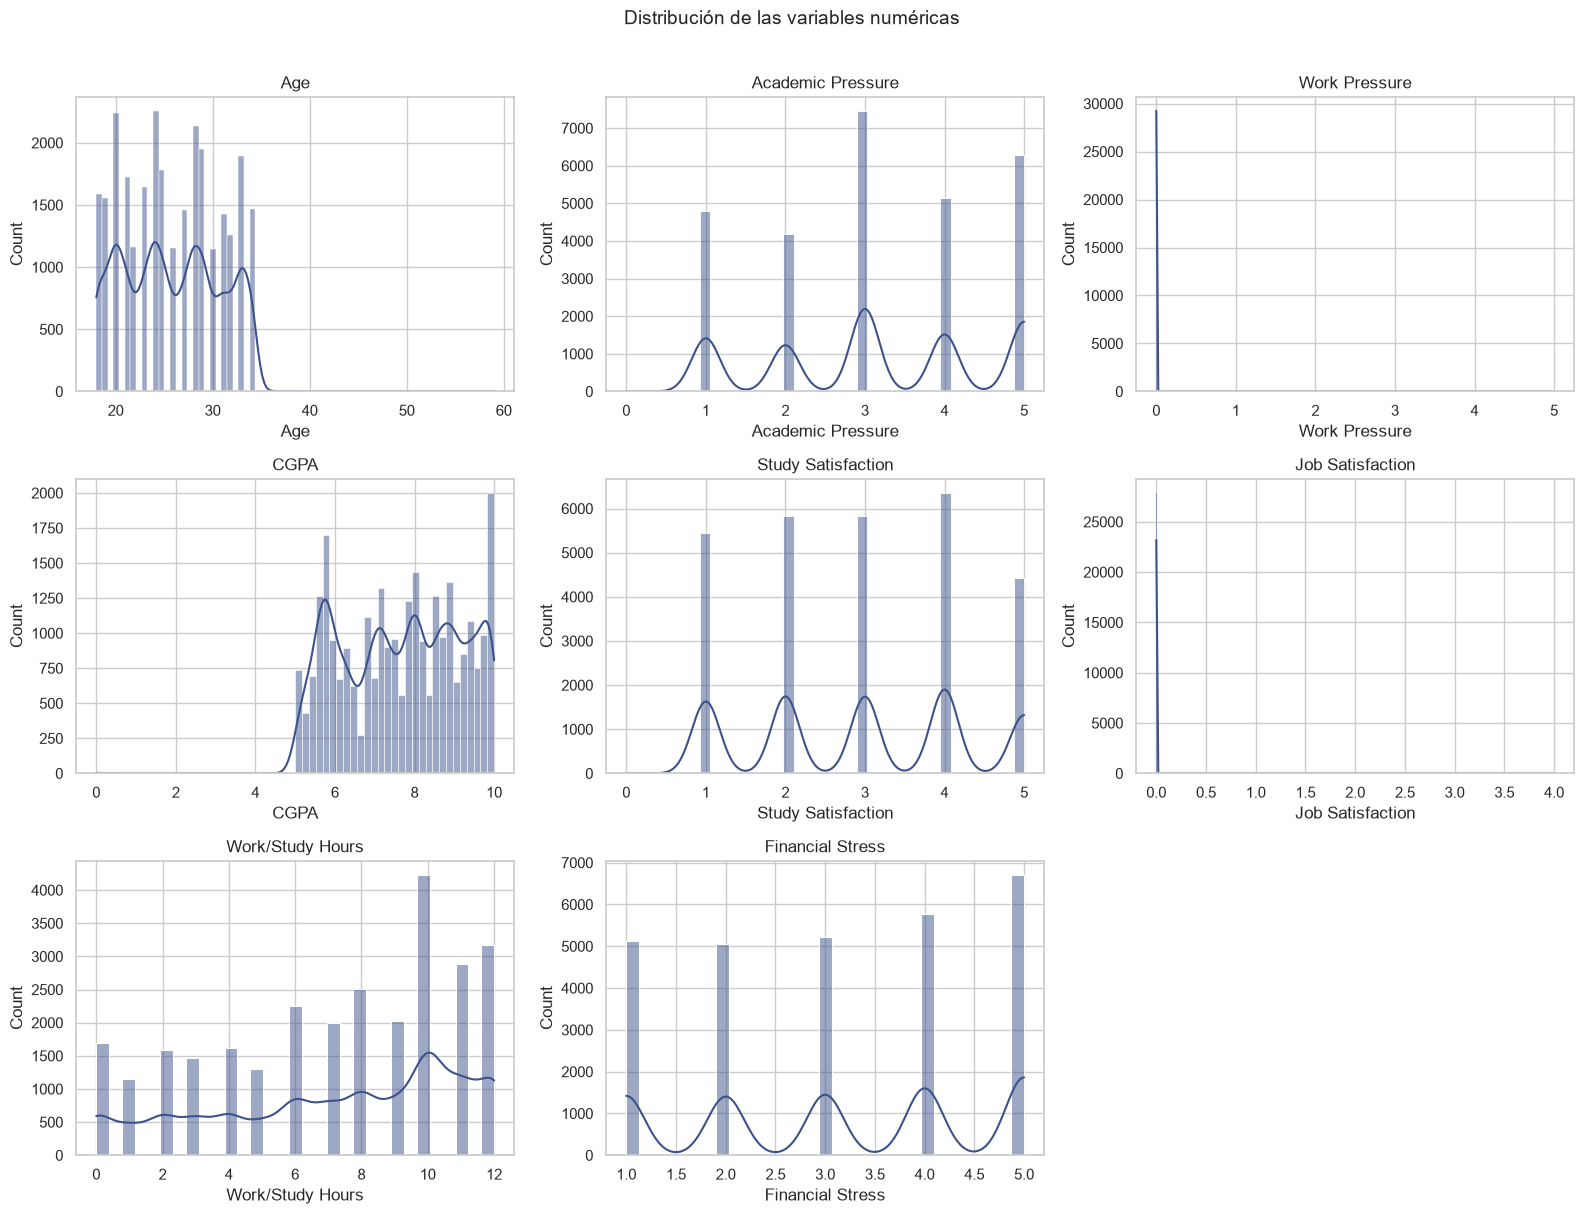

In [9]:
num_cols = [c for c in NUMERIC_FEATURES if c in df.columns]

fig, axes = plt.subplots(nrows=(len(num_cols) + 2) // 3, ncols=3, figsize=(16, 4 * ((len(num_cols) + 2) // 3)))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(data=df, x=col, kde=True, ax=ax, color="#3b528b")
    ax.set_title(col)
# Ocultar ejes sobrantes
for ax in axes.ravel()[len(num_cols):]:
    ax.set_visible(False)
fig.suptitle("Distribución de las variables numéricas", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Análisis univariado — variables categóricas

Frecuencia de cada categoría. Para variables de muy alta cardinalidad (p. ej. `City`)
mostramos solo las categorías más frecuentes.

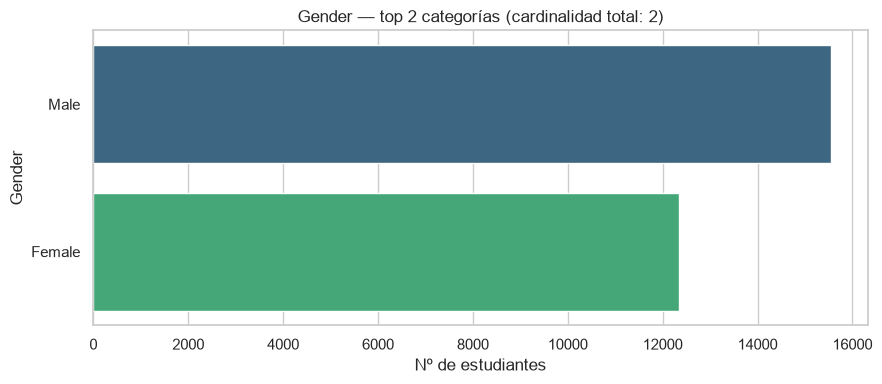

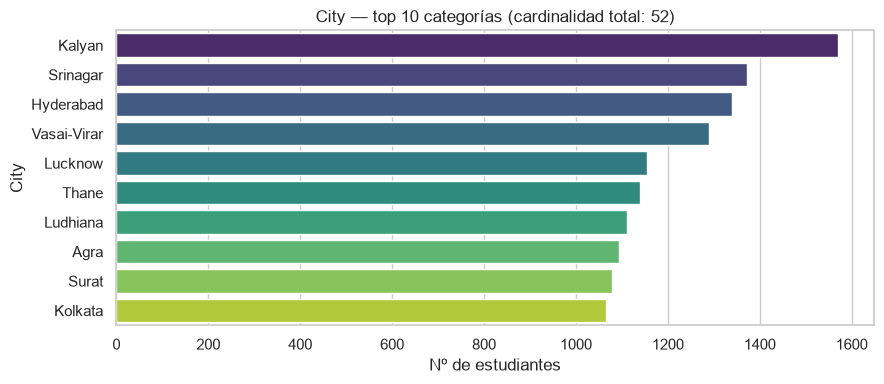

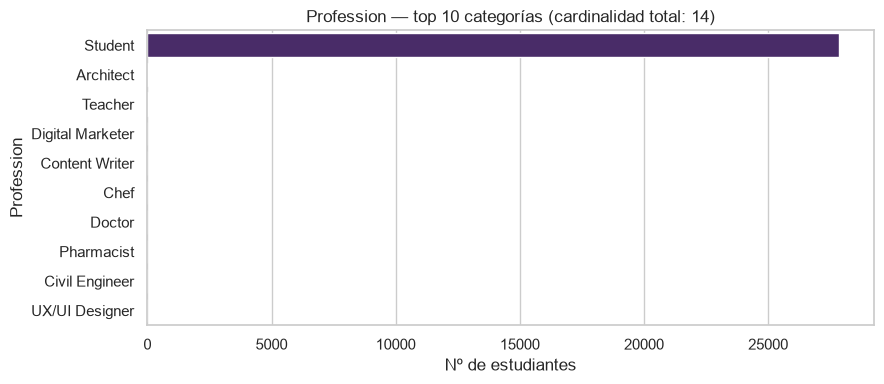

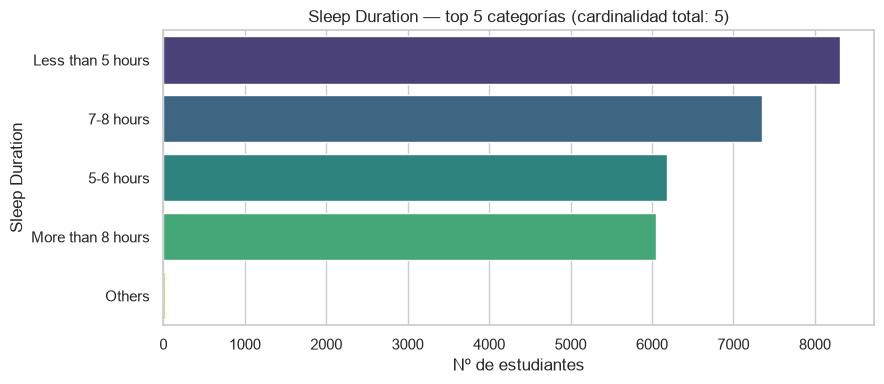

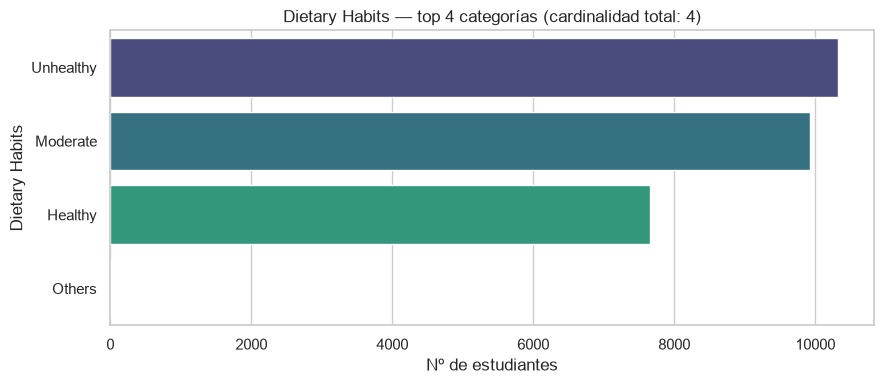

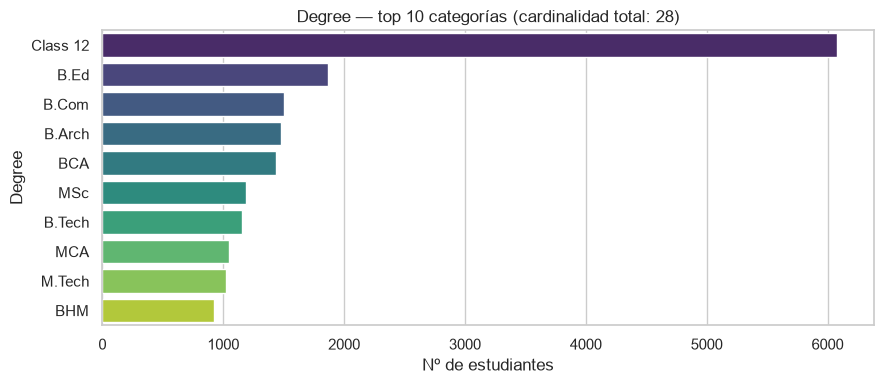

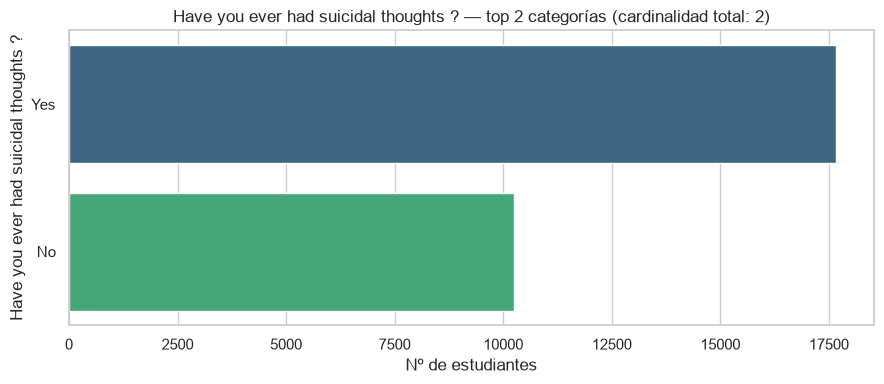

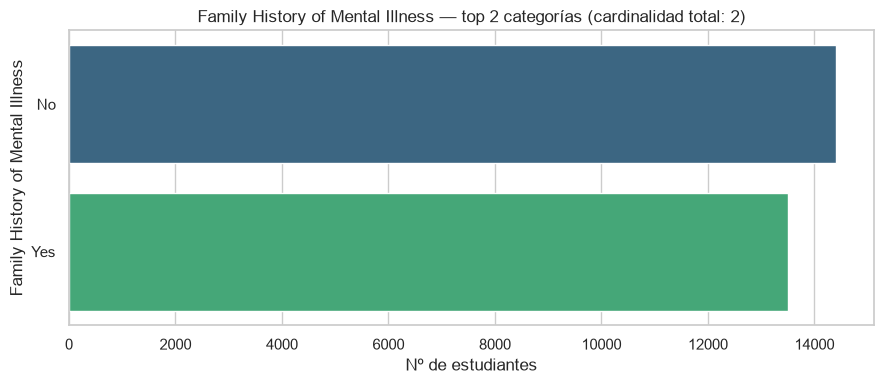

In [10]:
cat_cols = [c for c in CATEGORICAL_FEATURES if c in df.columns]

for col in cat_cols:
    top = df[col].value_counts().head(10)
    plt.figure(figsize=(9, 4))
    sns.barplot(x=top.values, y=top.index.astype(str), hue=top.index.astype(str), legend=False, palette="viridis")
    plt.title(f"{col} — top {len(top)} categorías (cardinalidad total: {df[col].nunique()})")
    plt.xlabel("Nº de estudiantes")
    plt.tight_layout()
    plt.show()

## 7. Correlaciones entre variables numéricas y el objetivo

Mapa de calor de correlaciones (Pearson). Incluimos el objetivo para ver qué variables
numéricas tienen mayor relación lineal con la depresión.

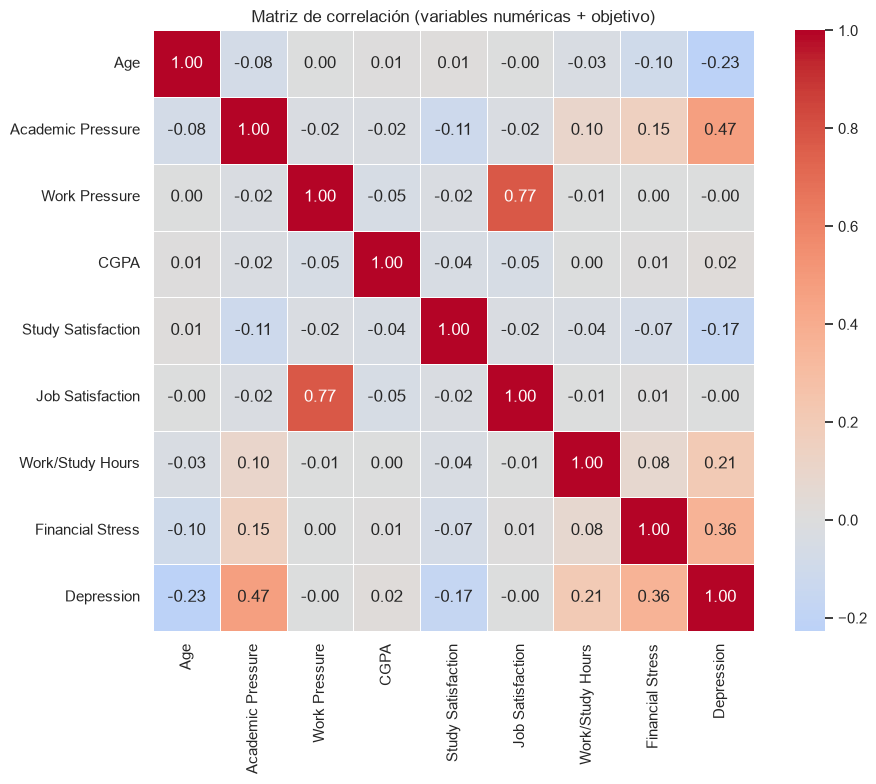

In [11]:
corr_cols = num_cols + [TARGET]
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Matriz de correlación (variables numéricas + objetivo)")
plt.tight_layout()
plt.show()

In [12]:
# Correlación de cada variable numérica con el objetivo, ordenada
corr_target = corr[TARGET].drop(TARGET).sort_values(ascending=False)
print("Correlación con Depression:")
corr_target

Correlación con Depression:


Academic Pressure     0.474835
Financial Stress      0.363591
Work/Study Hours      0.208563
CGPA                  0.022210
Work Pressure        -0.003351
Job Satisfaction     -0.003482
Study Satisfaction   -0.167971
Age                  -0.226422
Name: Depression, dtype: float64

## 8. Análisis bivariado — predictoras vs. objetivo

### 8.1 Variables numéricas vs. Depression
Comparamos la distribución de cada variable numérica según la persona tenga o no depresión.

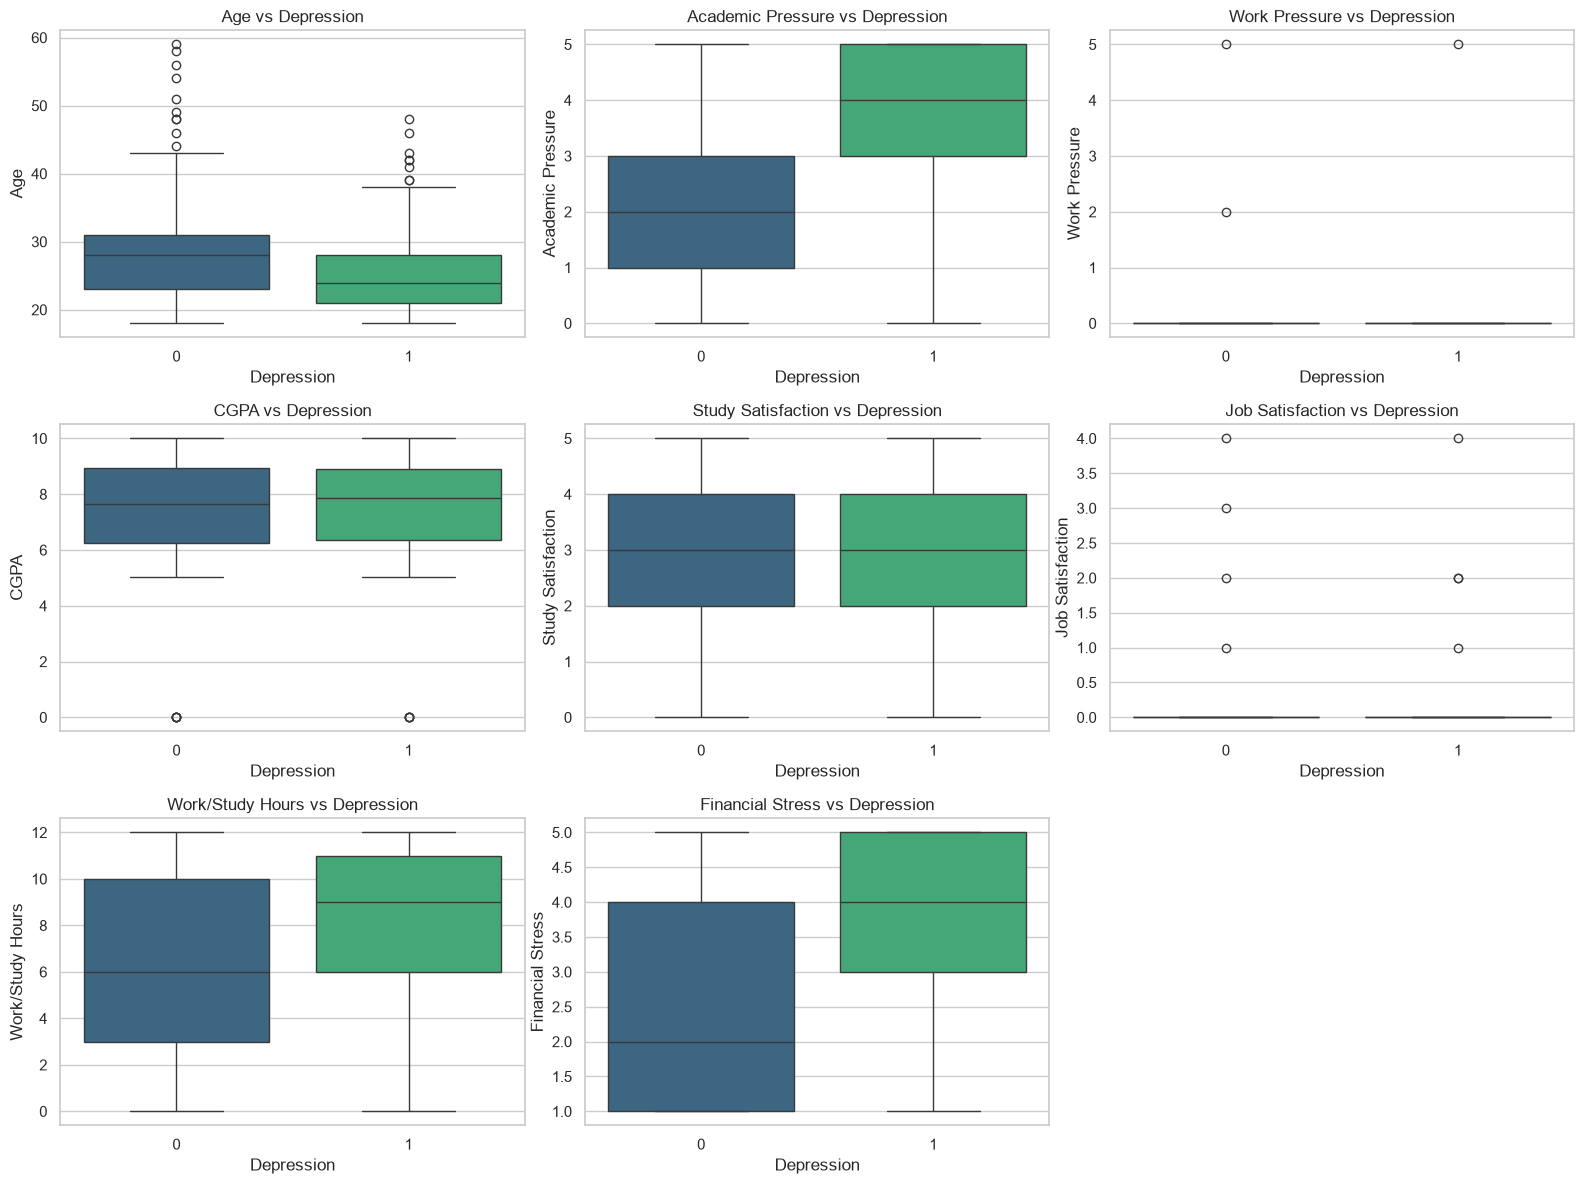

In [13]:
fig, axes = plt.subplots(nrows=(len(num_cols) + 2) // 3, ncols=3, figsize=(16, 4 * ((len(num_cols) + 2) // 3)))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(data=df, x=TARGET, y=col, hue=TARGET, legend=False, ax=ax, palette="viridis")
    ax.set_title(f"{col} vs Depression")
    ax.set_xlabel("Depression")
for ax in axes.ravel()[len(num_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

### 8.2 Variables categóricas vs. Depression
Calculamos la **tasa de depresión** (proporción de `Depression = 1`) dentro de cada categoría.

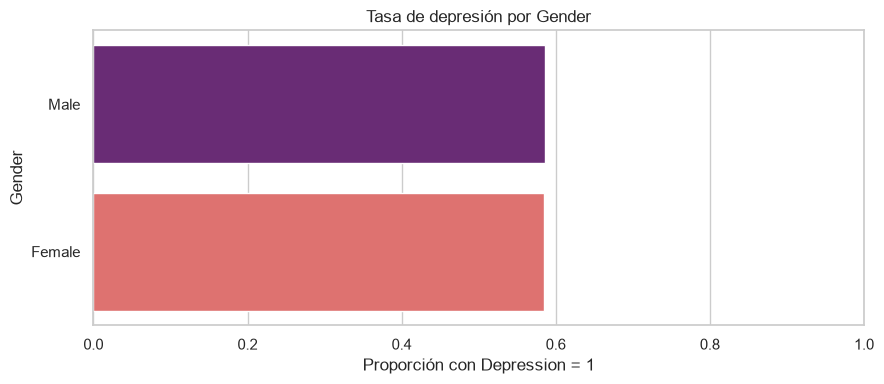

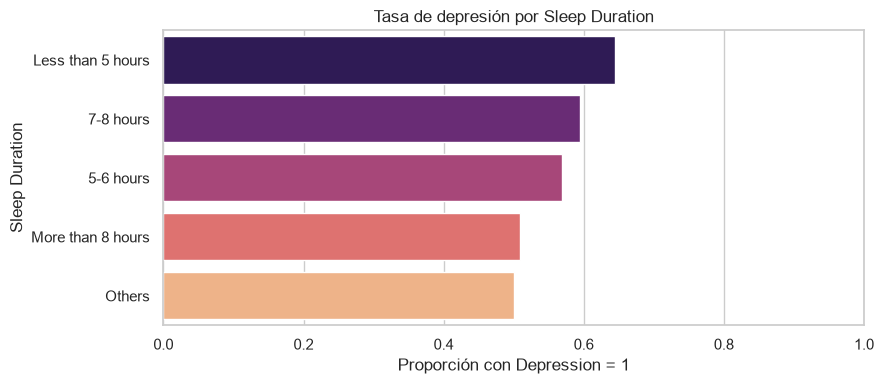

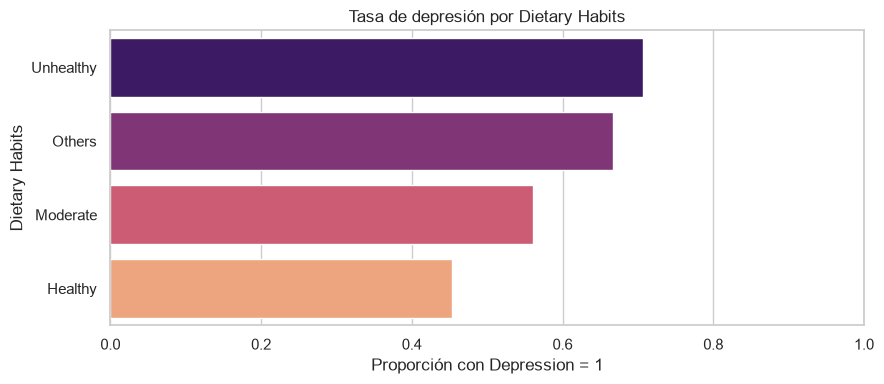

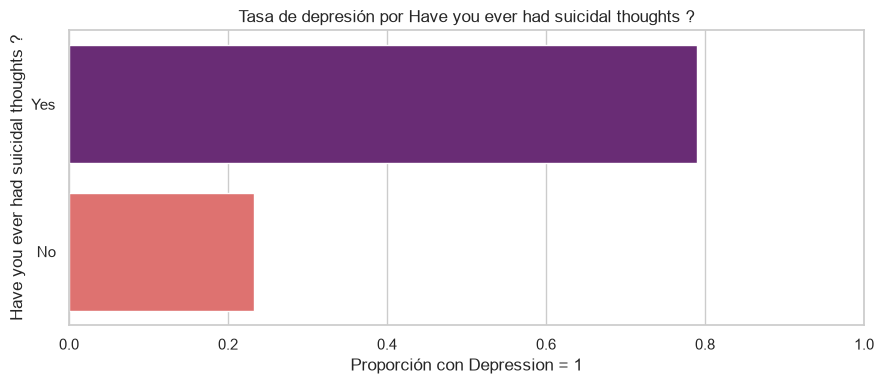

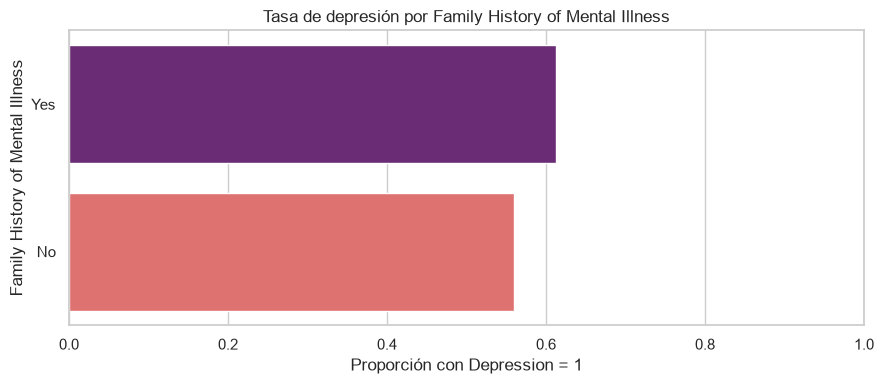

In [14]:
# Categóricas de cardinalidad baja/media para tasa de depresión
low_card_cats = [c for c in cat_cols if df[c].nunique() <= 12]

for col in low_card_cats:
    rate = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    plt.figure(figsize=(9, 4))
    sns.barplot(x=rate.values, y=rate.index.astype(str), hue=rate.index.astype(str), legend=False, palette="magma")
    plt.title(f"Tasa de depresión por {col}")
    plt.xlabel("Proporción con Depression = 1")
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()

## 9. Conclusiones del EDA

_Completa esta sección con lo observado al ejecutar el notebook. Puntos guía:_

- **Tamaño y calidad:** ~27,900 registros y 18 columnas. Revisar columnas con nulos y decidir estrategia de imputación.
- **Balance del objetivo:** verificar si `Depression` está balanceado (afecta la elección de métricas — usar F1/recall además de accuracy).
- **Variables más asociadas:** normalmente `Academic Pressure`, `Financial Stress`, `Work/Study Hours` y los antecedentes de pensamientos suicidas muestran fuerte relación con la depresión.
- **Cardinalidad:** `City`, `Profession` y `Degree` tienen alta cardinalidad → requieren encoding cuidadoso (Target/Frequency Encoding en lugar de One-Hot puro).
- **Siguientes pasos:** preprocesamiento (limpieza + encoding + escalado) → modelado → evaluación.

> Recuerda enmarcar cualquier hallazgo con la **advertencia ética**: son patrones estadísticos, no diagnósticos.